In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("results_nebulastream.csv")

df['system'] = 'NebulaStream'

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

df

,bytesPerSecond,query_name,time,tuplesPerSecond,tuplesPerSecond_listener,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,numberOfEntriesSliceCaches,sliceCacheType,bufferSizeInBytes,pageSize,system,synopsis_type,query_variant
0,1.586055e+08,ReservoirBuild_100,42.107701,4.369550e+06,4.350138e+06,COMPILER,1,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,100
1,1.557067e+08,ReservoirBuild_100,42.891631,4.289688e+06,4.287259e+06,COMPILER,4,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,100
2,1.211844e+08,ReservoirBuild_100,55.110348,3.338606e+06,3.334407e+06,COMPILER,16,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,100
3,1.578209e+08,ReservoirBuild_1000,42.317037,4.347935e+06,4.343416e+06,COMPILER,1,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,1000
4,1.265858e+08,ReservoirBuild_1000,52.758787,3.487414e+06,3.485540e+06,COMPILER,4,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,1000
5,9.997787e+07,ReservoirBuild_1000,66.799930,2.754370e+06,2.754347e+06,COMPILER,16,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,1000
6,1.539779e+08,ReservoirBuild_10000,43.373213,4.242059e+06,4.237158e+06,COMPILER,1,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,10000
7,1.368816e+08,ReservoirBuild_10000,48.790444,3.771061e+06,3.767872e+06,COMPILER,4,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,10000
8,1.099970e+08,ReservoirBuild_10000,60.715431,3.030395e+06,3.025153e+06,COMPILER,16,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,ReservoirBuild,10000
9,1.595744e+08,HistogramBuild_10_0_1000000_uint64,41.852050,4.396242e+06,4.396251e+06,COMPILER,1,20000,HASH_JOIN,10,SECOND_CHANCE,1048576,8192,NebulaStream,HistogramBuild,10_0_1000000_uint64


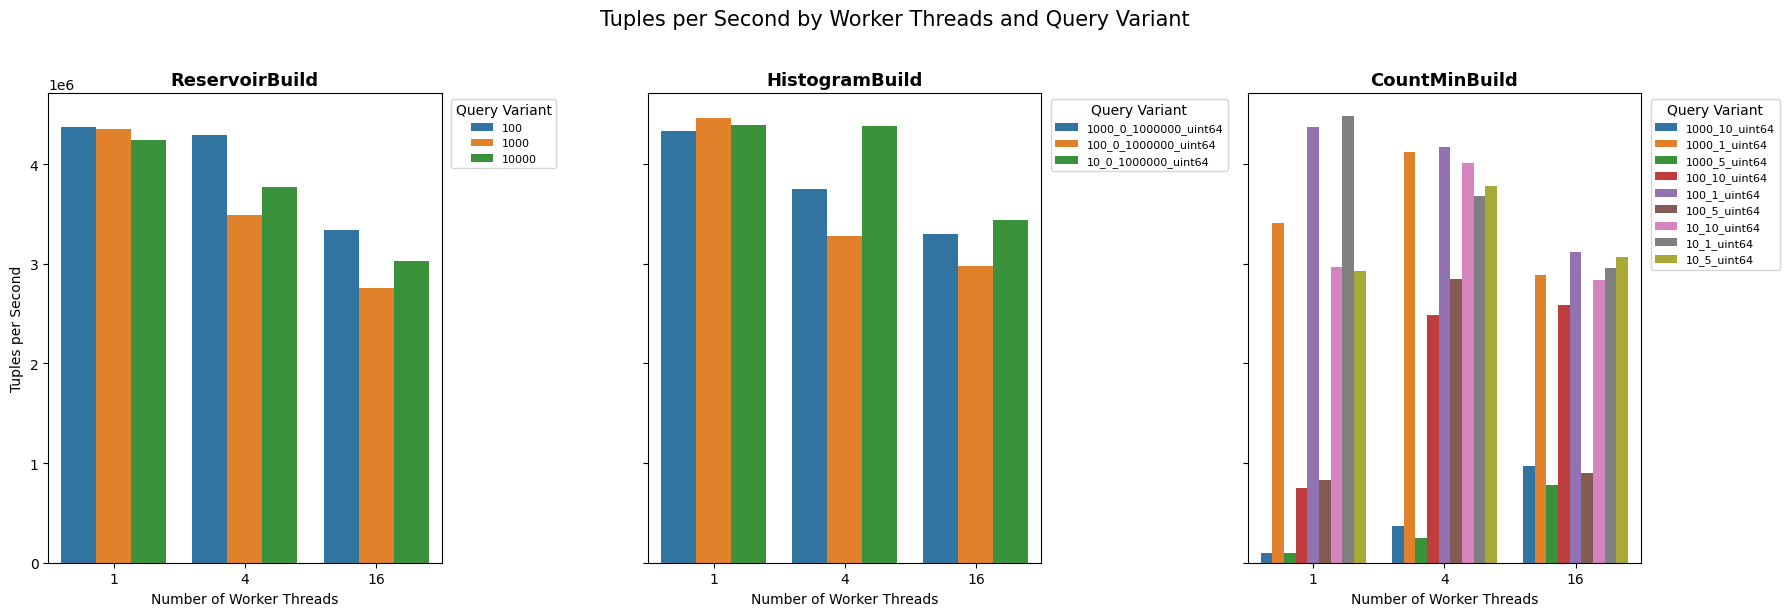

In [2]:
synopsis_types = df["synopsis_type"].unique()
n = len(synopsis_types)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

# Ensure axes is always iterable
if n == 1:
    axes = [axes]

for ax, synopsis in zip(axes, synopsis_types):
    subset = df[df["synopsis_type"] == synopsis]
    hue_order = sorted(subset["query_variant"].dropna().unique())
    palette = sns.color_palette("tab10", len(hue_order))

    sns.barplot(
        data=subset,
        x="numberOfWorkerThreads",
        y="tuplesPerSecond",
        hue="query_variant",
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        errorbar="sd",       # show standard deviation as error bars; use None to disable
    )

    ax.set_title(synopsis, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Worker Threads")
    ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
    ax.legend(title="Query Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Tuples per Second by Worker Threads and Query Variant", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()